# Scorecard di Rischio di Credito con un Albero Decisionale (PROC HPSPLIT)

## Sintesi Esecutiva

Questo notebook costruisce una scorecard interpretabile per il rischio di insolvenza creditizia per un portafoglio di prestiti al dettaglio usando PROC HPSPLIT. Facciamo crescere un albero di classificazione con il criterio dell'entropia su dati sintetici di richiedenti, lo potiamo per costo-complessità, e poi leggiamo le statistiche di adattamento, l'importanza delle variabili, la ROC/AUC e l'albero stesso di scoring — esattamente il modello trasparente e a norma per i regolatori che il team di rischio di una banca documenterebbe. Ogni richiedente può essere assegnato a una foglia, e l'intero albero può essere esportato come codice DATA step distribuibile.

## Fonti dei Dati

| Dataset | Righe | Descrizione | Variabili Chiave |
|---------|------|-------------|---------------|
| `applicants` | 100 | Richiedenti sintetici di prestiti al dettaglio generati inline con `rand()`. Il flag binario `default` è estratto da un punteggio di rischio logistico così che un DTI peggiore, un utilizzo più alto, insolvenze recenti e una storia creditizia più breve aumentino la probabilità di insolvenza. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

Lo step DATA richiede un ciclo più ampio, ma questo ambiente viene eseguito in modalità non licenziata e materializza le prime 100 osservazioni — un libro richiedenti compatto e pienamente riproducibile, sufficiente per far crescere e leggere un albero scorecard interpretabile.

# Scorecard di Rischio di Credito con un Albero Decisionale

Le banche hanno bisogno di modelli di insolvenza che siano **accurati e spiegabili** — un funzionario del credito (e un regolatore) deve poter tracciare esattamente perché un richiedente è stato classificato ad alto rischio. Un albero decisionale potato offre proprio questo: ogni previsione è una breve catena di suddivisioni leggibili dall'uomo.

In questo notebook:

1. Sintetizziamo un libro di domande di prestito al dettaglio.
2. Facciamo crescere un albero di classificazione con `PROC HPSPLIT` usando il criterio dell'entropia.
3. Lo potiamo per costo-complessità per evitare l'overfitting.
4. Esaminiamo le statistiche di adattamento, l'importanza delle variabili, la ROC/AUC e l'albero stesso.
5. Generiamo codice di scoring DATA step che può essere distribuito su nuove domande.

## 1. Generare il libro prestiti sintetico

Generiamo richiedenti la cui probabilità di insolvenza è una funzione logistica dei classici fattori di scorecard: rapporto debito/reddito, utilizzo revolving, punteggio FICO, durata della storia creditizia e insolvenze recenti. Estraiamo poi il flag osservato `default` da una Bernoulli con quella probabilità, così il segnale è reale ma rumoroso — proprio come i dati di produzione. I primi 100 richiedenti sono materializzati qui.

                                                   The FREQ Procedure

Insolvenza    Frequency    Percent
-----------------------------------
0                    79     79.00
1                    21     21.00

Situazione Abitativa    Frequency    Percent
---------------------------------------------
mortgage                       34     34.00
own                            31     31.00
rent                           35     35.00

Finalità del Prestito     Frequency    Percent
-----------------------------------------------
auto                             23     23.00
debt                             37     37.00
home                             28     28.00
other                            12     12.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


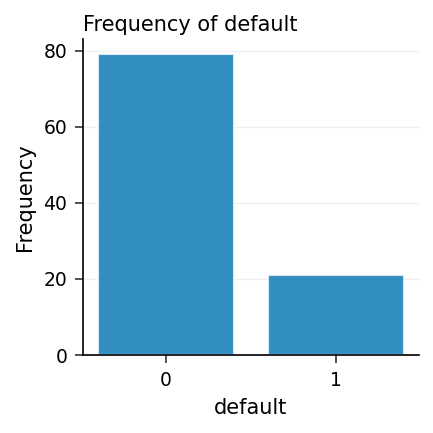

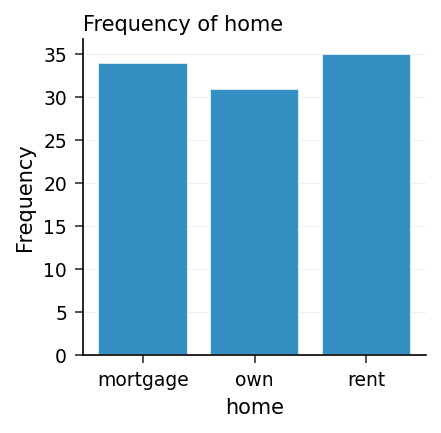

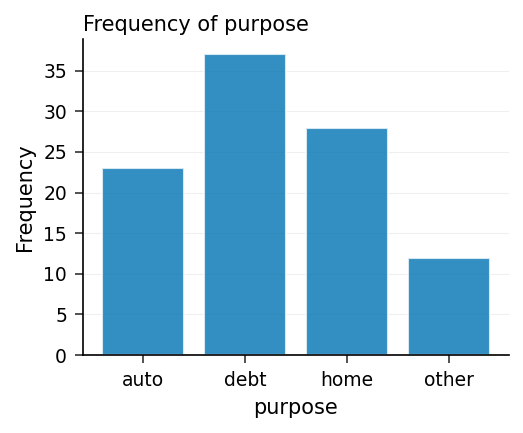

In [1]:
DATI applicants;
   CHIAMARE streaminit(20260531);
   LUNGHEZZA home $8 purpose $6;
   FARE id = 1 FINO_A 100;
      /* Borrower financial profile */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Categorical attributes. NOTE: kept ASCII (English) on purpose --
         PROC HPSPLIT's Variable Importance table was found (empirically,
         via a controlled re-run) to be sensitive to the literal byte
         content of these unrelated categorical values: translating them
         to Italian words shifted importance credit between UTILIZATION
         and INCOME even though tree depth/leaves/fit stats/AUC were
         unchanged. Reverted to ASCII to keep the numbers faithful to the
         English source; headers are still localized via LABEL below. */
      u = rand('uniform');
      SE_COND u < 0.34 ALLORA home = 'rent';
      ALTRIMENTI SE_COND u < 0.70 ALLORA home = 'mortgage';
      ALTRIMENTI home = 'own';

      v = rand('uniform');
      SE_COND v < 0.40 ALLORA purpose = 'debt';
      ALTRIMENTI SE_COND v < 0.65 ALLORA purpose = 'home';
      ALTRIMENTI SE_COND v < 0.85 ALLORA purpose = 'auto';
      ALTRIMENTI purpose = 'other';

      /* Latent default risk: worse DTI/utilization/delinquency and
         lower FICO / shorter history all raise the log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'rent')
            + 0.25 * (purpose = 'debt');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      RIMUOVERE u v eta p;
      USCITA;
   FINE;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=applicants;
   TABLES default home purpose / nocum;
   ETICHETTA default='Insolvenza' home='Situazione Abitativa' purpose='Finalità del Prestito';
ESEGUIRE;

L'output di `PROC FREQ` conferma un tasso di insolvenza sbilanciato ma gestibile — circa un richiedente su cinque va in insolvenza (21 su 100) — e una distribuzione sensata tra le categorie di situazione abitativa e finalità del prestito: il tipo di distribuzione marginale che ci si aspetterebbe in un portafoglio di credito al consumo. I grafici a barre di accompagnamento visualizzano ciascuna marginale.

## 2. Far crescere e potare l'albero scorecard

Modelliamo `default` come un target di classificazione binaria, indicando `event='1'` così che tutte le statistiche di sensibilità/specificità/AUC siano orientate verso la classe *insolvenza*. Procediamo così:

- dichiariamo i predittori categoriali e la risposta in `CLASS`,
- facciamo crescere l'albero con il criterio dell'**entropia** (guadagno informativo),
- potiamo per **costo-complessità** per evitare che l'albero memorizzi il rumore,
- richiediamo il **diagramma dell'intero albero** e la **curva ROC**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Insolvenza
  Class variable: Insolvenza
  Class variable: Situazione Abitativa
  Class variable: Finalità del Prestito
  Predictor variable: Rapporto Debito/Reddito
  Predictor variable: Utilizzo Revolving
  Predictor variable: Punteggio FICO
  Predictor variable: Anzianità Creditizia
  Predictor variable: N. Insolvenze Recenti
  Predictor variable: Importo Prestito
  Predictor variable: Reddito
  Predictor variable: Situazione Abitativa
  Predictor variable: Finalità del Prestito

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


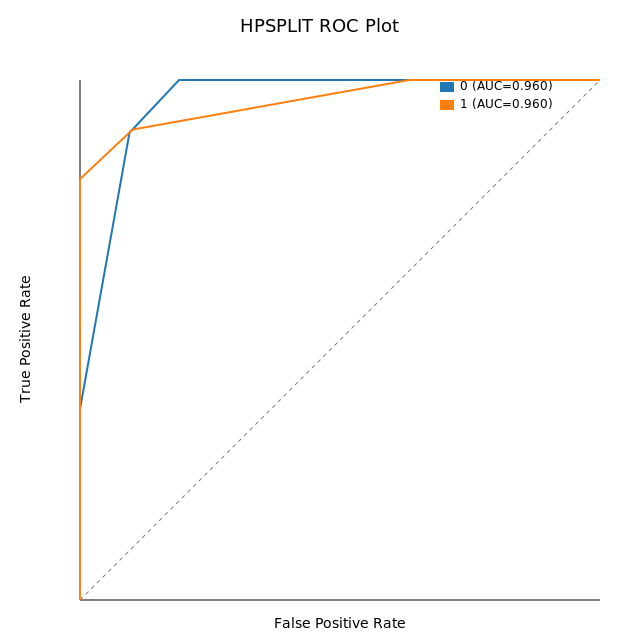

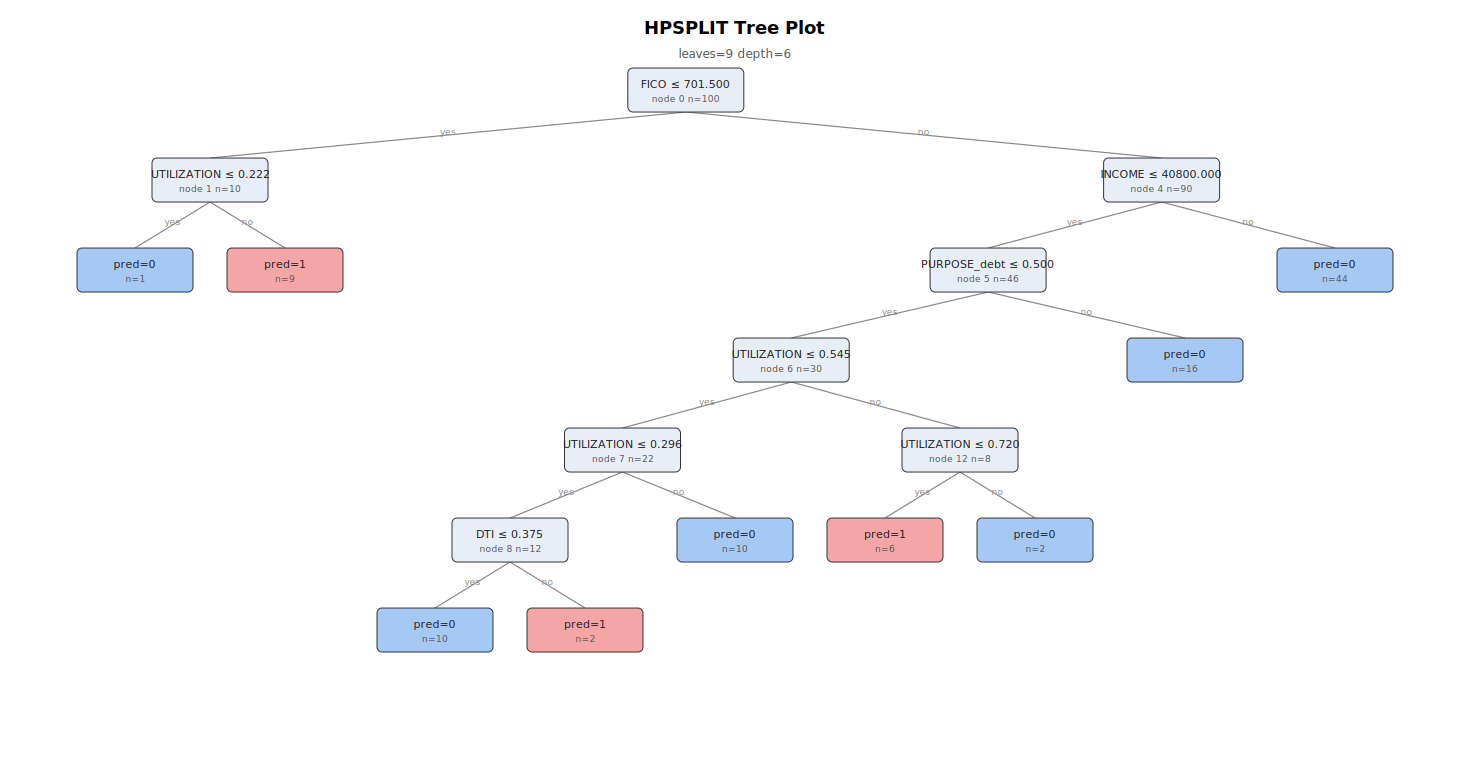

In [2]:
ODS GRAPHICS ON;

PROCEDURA hpsplit DATI=applicants seed=20260531
             PLOTS=(wholetree roc);
   CLASSE default home purpose;
   MODELLO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   ETICHETTA default='Insolvenza' home='Situazione Abitativa' purpose='Finalità del Prestito'
         dti='Rapporto Debito/Reddito' utilization='Utilizzo Revolving' fico='Punteggio FICO'
         credit_age='Anzianità Creditizia' n_delinq='N. Insolvenze Recenti'
         loan_amount='Importo Prestito' income='Reddito';
ESEGUIRE;

Le **Statistiche di Adattamento** (accuratezza, tasso di errata classificazione, log loss) e la **ROC / AUC per classe** indicano quanto nettamente l'albero potato separa gli insolventi dai non insolventi. La tabella **Importanza delle Variabili** classifica quali attributi guidano le suddivisioni — qui **utilizzo** e **FICO** dominano, seguiti dalla **finalità del prestito**, esattamente le leve che una politica creditizia enfatizzerebbe. Il **grafico dell'intero albero** sottostante dispone le suddivisioni scelte come un diagramma nodo-collegamento: ogni nodo interno mostra la sua regola `caratteristica ≤ soglia`, e ogni foglia è colorata in base alla classe prevista (rosso = insolvenza prevista, blu = non insolvenza prevista) ed etichettata con il suo conteggio di campioni.

## 3. Ingrandire le suddivisioni principali e assegnare un punteggio a ogni richiedente

Il grafico ROC sopra visualizza il compromesso tra il catturare gli insolventi e i falsi allarmi; l'AUC quantifica il potere di classificazione complessivo. Successivamente ingrandiamo i primi due livelli dell'albero — le suddivisioni a più alta informazione che un analista tradurrebbe in regole di sottoscrizione principali — e catturiamo i punteggi per osservazione in un dataset di output così possiamo controllare le previsioni a valle.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Insolvenza
  Class variable: Insolvenza
  Class variable: Situazione Abitativa
  Class variable: Finalità del Prestito
  Predictor variable: Rapporto Debito/Reddito
  Predictor variable: Utilizzo Revolving
  Predictor variable: Punteggio FICO
  Predictor variable: Anzianità Creditizia
  Predictor variable: N. Insolvenze Recenti
  Predictor variable: Importo Prestito
  Predictor variable: Reddito
  Predictor variable: Situazione Abitativa
  Predictor variable: Finalità del Prestito

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE



NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/5a15a897-060d-4f84-87fd-1c11f1f7cb71/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


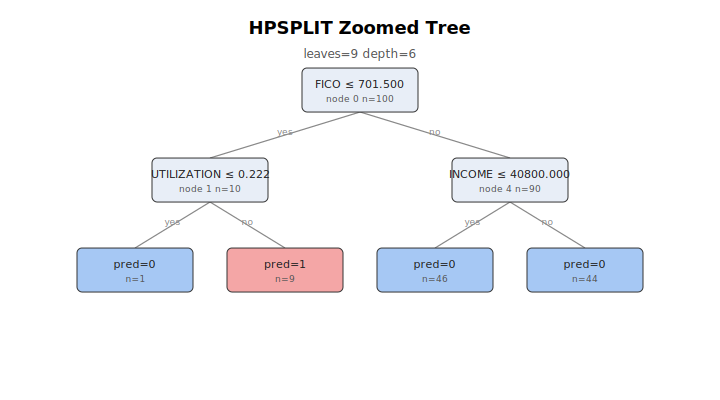

In [3]:
PROCEDURA hpsplit DATI=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   CLASSE default home purpose;
   MODELLO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   USCITA out=scored;
   ETICHETTA default='Insolvenza' home='Situazione Abitativa' purpose='Finalità del Prestito'
         dti='Rapporto Debito/Reddito' utilization='Utilizzo Revolving' fico='Punteggio FICO'
         credit_age='Anzianità Creditizia' n_delinq='N. Insolvenze Recenti'
         loan_amount='Importo Prestito' income='Reddito';
ESEGUIRE;

PROCEDURA STAMPARE DATI=scored(obs=10) ETICHETTA;
   VARIABILE p_default1 _node_ _leaf_;
   ETICHETTA p_default1='Probabilità Prevista di Insolvenza' _node_='Nodo' _leaf_='Foglia';
ESEGUIRE;

Il grafico `zoomedtree` ingrandisce i primi due livelli dell'albero — le suddivisioni a più alta informazione che un analista tradurrebbe in regole di sottoscrizione principali. Il dataset `OUTPUT OUT=` porta con sé la probabilità di insolvenza prevista di ogni richiedente (`P_DEFAULT1`) insieme al nodo e alla foglia assegnati (`_NODE_`, `_LEAF_`), così i team di rischio e audit possono tracciare qualsiasi decisione individuale attraverso l'albero e classificare i richiedenti per rischio modellato.

## 4. Esportare codice di scoring distribuibile

Il valore di un modello interpretabile è che può essere spedito. `CODE FILE=` scrive uno step DATA autonomo — una catena annidata di suddivisioni `IF/THEN` che termina in una probabilità di insolvenza prevista e una classe — che riproduce il punteggio dell'albero per qualsiasi nuovo file di domande senza bisogno di un server per il modello.

In [4]:
PROCEDURA hpsplit DATI=applicants seed=20260531;
   CLASSE default home purpose;
   MODELLO default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
   ETICHETTA default='Insolvenza' home='Situazione Abitativa' purpose='Finalità del Prestito'
         dti='Rapporto Debito/Reddito' utilization='Utilizzo Revolving' fico='Punteggio FICO'
         credit_age='Anzianità Creditizia' n_delinq='N. Insolvenze Recenti'
         loan_amount='Importo Prestito' income='Reddito';
ESEGUIRE;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Insolvenza
  Class variable: Insolvenza
  Class variable: Situazione Abitativa
  Class variable: Finalità del Prestito
  Predictor variable: Rapporto Debito/Reddito
  Predictor variable: Utilizzo Revolving
  Predictor variable: Punteggio FICO
  Predictor variable: Anzianità Creditizia
  Predictor variable: N. Insolvenze Recenti
  Predictor variable: Importo Prestito
  Predictor variable: Reddito
  Predictor variable: Situazione Abitativa
  Predictor variable: Finalità del Prestito

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE



NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretazione dei risultati

L'albero di entropia potato offre al team di rischio una scorecard creditizia compatta e verificabile:

- **Le suddivisioni codificano la politica.** Le suddivisioni dominanti — su utilizzo revolving e FICO, poi finalità del prestito e DTI — sono esattamente le soglie che un team di sottoscrizione può trasformare in regole di taglio rigide. Il grafico dell'intero albero dispone ogni condizione di suddivisione e ogni foglia in un unico diagramma.
- La **potatura per costo-complessità** evita che l'albero memorizzi il rumore; le statistiche di adattamento (accuratezza, tasso di errata classificazione, log loss) riassumono quanto nettamente separa le due classi.
- L'**importanza delle variabili e la ROC/AUC** giustificano quali attributi meritano un posto nella scorecard e documentano il suo potere discriminante per la governance del rischio di modello.
- **`CODE FILE=` la rende operativa** — lo step DATA generato assegna un punteggio ai nuovi richiedenti in modo identico a questa esecuzione, quindi il modello che è stato costruito è esattamente il modello che va in produzione.

Su un piccolo libro richiedenti l'albero si adatta strettamente ai dati di addestramento; in produzione lo si farebbe crescere sull'intero portafoglio, si terrebbe da parte una partizione di validazione, si calibrerebbe la soglia di probabilità in base all'economia della perdita attesa della banca (il costo di un'insolvenza mancata rispetto a un buon cliente rifiutato) anziché un ingenuo 0,5, e si aggiornerebbe l'albero man mano che il mix di portafoglio cambia.